In [1]:
import re
from pathlib import Path
import pandas as pd

log_path = Path(r"smoothing-48500580.out")
text = log_path.read_text(encoding="utf-8")

pattern = re.compile(
    r"\[(\d+)/500\]\s+idx=(\d+)\s+true=(.+?)\s{2}orig=(.+?)\s{2}"
    r"manifold=(.+?)\((\d+)/100\)\s{2}gauss=(.+?)\((\d+)/100\)\s{2}"
    r"m_stable=(True|False)\s{2}g_stable=(True|False)"
)

rows = []
for m in pattern.finditer(text):
    rows.append({
        "num": int(m.group(1)),
        "idx": int(m.group(2)),
        "true_class": m.group(3).strip(),
        "orig_pred": m.group(4).strip(),
        "manifold_pred": m.group(5).strip(),
        "manifold_votes": int(m.group(6)),
        "gauss_pred": m.group(7).strip(),
        "gauss_votes": int(m.group(8)),
        "m_stable": m.group(9) == "True",
        "g_stable": m.group(10) == "True",
    })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} / 500 results")
df.head()

Parsed 500 / 500 results


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes,gauss_pred,gauss_votes,m_stable,g_stable
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68,"unicycle, monocycle",35,False,True
1,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52,wire-haired fox terrier,13,True,False
2,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66,sturgeon,19,False,False
3,4,12447,"Eskimo dog, husky","dingo, warrigal, warragal, Canis dingo","timber wolf, grey wolf, gray wolf, Canis lupus",36,"timber wolf, grey wolf, gray wolf, Canis lupus",11,False,False
4,5,39489,shoji,shoji,chest,25,shoji,16,False,True


In [2]:
# === Summary Statistics ===
n = len(df)
m_stable = df["m_stable"].sum()
g_stable = df["g_stable"].sum()

# Orig accuracy (orig_pred == true_class)
df["orig_correct"] = df["orig_pred"] == df["true_class"]
df["manifold_correct"] = df["manifold_pred"] == df["true_class"]
df["gauss_correct"] = df["gauss_pred"] == df["true_class"]

# Manifold preserves original prediction
df["manifold_preserves_orig"] = df["manifold_pred"] == df["orig_pred"]
df["gauss_preserves_orig"] = df["gauss_pred"] == df["orig_pred"]

summary = pd.DataFrame({
    "Metric": [
        "Total images",
        "Certified stable",
        "Certified stable (%)",
        "Mean top-class votes",
        "Median top-class votes",
        "Preserves orig pred",
        "Preserves orig pred (%)",
        "Correct (matches true label)",
    ],
    "Manifold Smoothing": [
        n,
        int(m_stable),
        f"{m_stable/n*100:.1f}%",
        f"{df['manifold_votes'].mean():.1f}",
        f"{df['manifold_votes'].median():.0f}",
        int(df['manifold_preserves_orig'].sum()),
        f"{df['manifold_preserves_orig'].mean()*100:.1f}%",
        f"{df['manifold_correct'].sum()} ({df['manifold_correct'].mean()*100:.1f}%)",
    ],
    "Gaussian (Isotropic)": [
        n,
        int(g_stable),
        f"{g_stable/n*100:.1f}%",
        f"{df['gauss_votes'].mean():.1f}",
        f"{df['gauss_votes'].median():.0f}",
        int(df['gauss_preserves_orig'].sum()),
        f"{df['gauss_preserves_orig'].mean()*100:.1f}%",
        f"{df['gauss_correct'].sum()} ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
})

print("Original model accuracy on these 500 images:", f"{df['orig_correct'].mean()*100:.1f}%")
print()
summary.style.hide(axis='index')

Original model accuracy on these 500 images: 68.8%



Metric,Manifold Smoothing,Gaussian (Isotropic)
Total images,500,500
Certified stable,396,407
Certified stable (%),79.2%,81.4%
Mean top-class votes,72.1,27.4
Median top-class votes,75,23
Preserves orig pred,396,407
Preserves orig pred (%),79.2%,81.4%
Correct (matches true label),324 (64.8%),327 (65.4%)


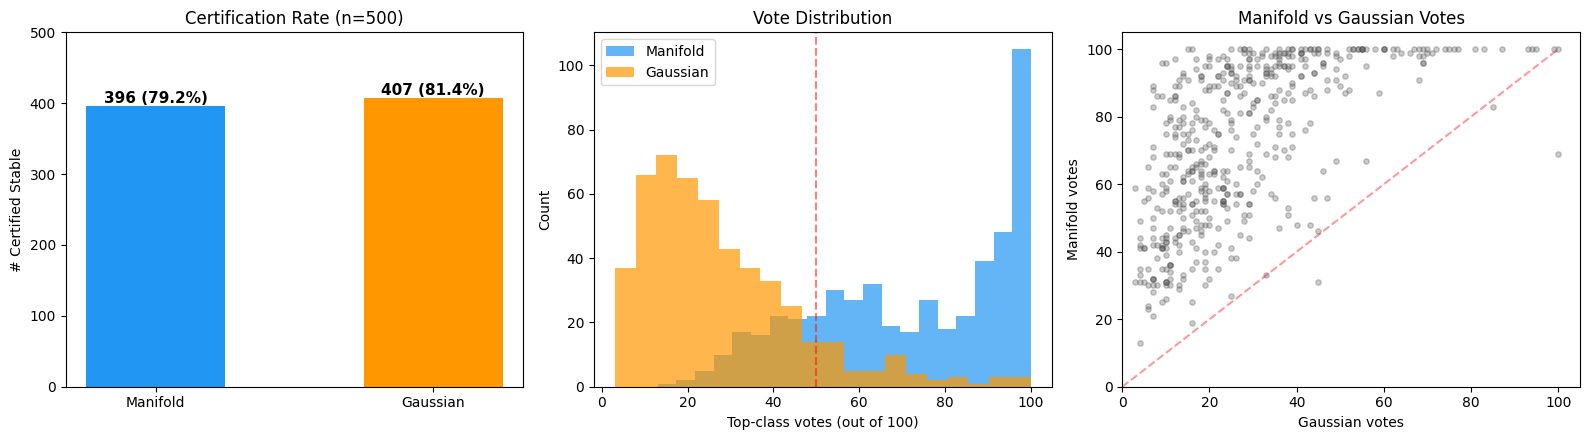

Saved: smoothing_results_summary.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1) Bar chart: certified stable
ax = axes[0]
bars = ax.bar(["Manifold", "Gaussian"], [m_stable, g_stable], 
              color=["#2196F3", "#FF9800"], width=0.5)
ax.set_ylabel("# Certified Stable")
ax.set_title(f"Certification Rate (n={n})")
ax.set_ylim(0, n)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, 
            f"{b.get_height():.0f} ({b.get_height()/n*100:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")

# 2) Vote distribution histogram
ax = axes[1]
ax.hist(df["manifold_votes"], bins=20, alpha=0.7, label="Manifold", color="#2196F3")
ax.hist(df["gauss_votes"], bins=20, alpha=0.7, label="Gaussian", color="#FF9800")
ax.set_xlabel("Top-class votes (out of 100)")
ax.set_ylabel("Count")
ax.set_title("Vote Distribution")
ax.legend()
ax.axvline(50, color="red", ls="--", alpha=0.5, label="majority")

plt.tight_layout()
plt.savefig("smoothing_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: smoothing_results_summary.png")

In [12]:
# === Detailed Breakdown ===
print("=" * 60)
print("STABILITY CROSS-TABLE")
print("=" * 60)
ct = pd.crosstab(df["m_stable"], df["g_stable"], 
                 rownames=["Manifold Stable"], colnames=["Gaussian Stable"],
                 margins=True)
print(ct)
print()
print(f"Both stable:           {((df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Only manifold stable:  {((df['m_stable']) & (~df['g_stable'])).sum()}")
print(f"Only gaussian stable:  {((~df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Neither stable:        {((~df['m_stable']) & (~df['g_stable'])).sum()}")

STABILITY CROSS-TABLE
Gaussian Stable  False  True  All
Manifold Stable                  
False               42    62  104
True                51   345  396
All                 93   407  500

Both stable:           345
Only manifold stable:  51
Only gaussian stable:  62
Neither stable:        42


In [13]:
# === Simple Results Comparison ===

results_table = pd.DataFrame({
    "": ["Original (no noise)", "Manifold Smoothed", "Gaussian Smoothed"],
    "Matches True Label": [
        f"{df['orig_correct'].sum()}/500 ({df['orig_correct'].mean()*100:.1f}%)",
        f"{df['manifold_correct'].sum()}/500 ({df['manifold_correct'].mean()*100:.1f}%)",
        f"{df['gauss_correct'].sum()}/500 ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
    "Certified Stable": [
        "—",
        f"{df['m_stable'].sum()}/500 ({df['m_stable'].mean()*100:.1f}%)",
        f"{df['g_stable'].sum()}/500 ({df['g_stable'].mean()*100:.1f}%)",
    ],
    "Mean Votes": [
        "—",
        f"{df['manifold_votes'].mean():.1f}/100",
        f"{df['gauss_votes'].mean():.1f}/100",
    ],
}).set_index("")

display(results_table)

# Head-to-head: true label
both = (df["manifold_correct"] & df["gauss_correct"]).sum()
only_m = (df["manifold_correct"] & ~df["gauss_correct"]).sum()
only_g = (~df["manifold_correct"] & df["gauss_correct"]).sum()
none_ = (~df["manifold_correct"] & ~df["gauss_correct"]).sum()

h2h = pd.DataFrame({
    "": ["Both correct", "Only Manifold correct", "Only Gaussian correct", "Neither correct"],
    "Count": [both, only_m, only_g, none_],
}).set_index("")

print("\nHead-to-head (which method matches TRUE label):")
display(h2h)

,Matches True Label,Certified Stable,Mean Votes
,,,
Original (no noise),344/500 (68.8%),—,—
Manifold Smoothed,324/500 (64.8%),396/500 (79.2%),72.1/100
Gaussian Smoothed,327/500 (65.4%),407/500 (81.4%),27.4/100



Head-to-head (which method matches TRUE label):


,Count
,
Both correct,284
Only Manifold correct,40
Only Gaussian correct,43
Neither correct,133


In [15]:
# === Cases where method is UNSTABLE but corrects to true label ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    corrects = df[~df[stable_col] & df[correct_col] & ~df["orig_correct"]]
    print(f"{method} UNSTABLE but corrects to true label: {len(corrects)}")
    if len(corrects) > 0:
        display(corrects[["num","idx","true_class","orig_pred",pred_col,votes_col]].reset_index(drop=True))
    print()

# === Cases where method is STABLE but wrong (orig was already wrong) ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    stable_wrong = df[df[stable_col] & ~df["orig_correct"]]
    print(f"{method} STABLE but wrong (orig was wrong too): {len(stable_wrong)}")
    if len(stable_wrong) > 0:
        display(stable_wrong[["num","idx","true_class","orig_pred",pred_col,votes_col]].head(15).reset_index(drop=True))
    print()

Manifold UNSTABLE but corrects to true label: 21


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68
1,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66
2,30,33109,modem,"hard disc, hard disk, fixed disk",modem,44
3,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",54
4,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",21
5,66,20304,altar,throne,altar,65
6,74,26803,"dock, dockage, docking facility","paddlewheel, paddle wheel","dock, dockage, docking facility",43
7,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",48
8,117,9801,miniature schnauzer,Kerry blue terrier,miniature schnauzer,63
9,122,7134,dowitcher,"red-backed sandpiper, dunlin, Erolia alpina",dowitcher,49



Gaussian UNSTABLE but corrects to true label: 15


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,wire-haired fox terrier,13
1,29,37237,"projectile, missile",missile,"projectile, missile",24
2,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",16
3,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",7
4,104,36537,"plow, plough",oxcart,"plow, plough",11
5,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",20
6,121,31919,maillot,"maillot, tank suit",maillot,22
7,223,48525,alp,"valley, vale",alp,29
8,280,147,"great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...",19
9,283,43850,turnstile,"tricycle, trike, velocipede",turnstile,10



Manifold STABLE but wrong (orig was wrong too): 93


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,61
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,70
3,23,821,bulbul,bee eater,bee eater,76
4,29,37237,"projectile, missile",missile,missile,64
5,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",59
6,34,3918,tick,rhinoceros beetle,rhinoceros beetle,51
7,44,38340,rotisserie,safe,safe,91
8,51,24712,"chime, bell, gong",tile roof,tile roof,58
9,65,37213,"projectile, missile","aircraft carrier, carrier, flattop, attack air...","aircraft carrier, carrier, flattop, attack air...",82



Gaussian STABLE but wrong (orig was wrong too): 95


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","unicycle, monocycle",35
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,16
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,16
3,23,821,bulbul,bee eater,bee eater,42
4,24,15118,"ground beetle, carabid beetle",tiger beetle,tiger beetle,23
5,30,33109,modem,"hard disc, hard disk, fixed disk","hard disc, hard disk, fixed disk",4
6,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",10
7,40,11076,Irish water spaniel,standard poodle,standard poodle,22
8,47,14644,"tiger, Panthera tigris","lynx, catamount","lynx, catamount",31
9,51,24712,"chime, bell, gong",tile roof,tile roof,7


In [16]:
# === Vote statistics for stable vs unstable ===
print("Mean manifold votes when STABLE:  ", df.loc[df['m_stable'], 'manifold_votes'].mean().round(1))
print("Mean manifold votes when UNSTABLE:", df.loc[~df['m_stable'], 'manifold_votes'].mean().round(1))
print()
print("Mean gaussian votes when STABLE:  ", df.loc[df['g_stable'], 'gauss_votes'].mean().round(1))
print("Mean gaussian votes when UNSTABLE:", df.loc[~df['g_stable'], 'gauss_votes'].mean().round(1))

Mean manifold votes when STABLE:   78.7
Mean manifold votes when UNSTABLE: 46.6

Mean gaussian votes when STABLE:   30.9
Mean gaussian votes when UNSTABLE: 12.3


In [17]:
# === Save parsed results as CSV ===
df.to_csv("smoothing_results_500.csv", index=False)
print("Saved: smoothing_results_500.csv")
print(f"\nManifold: {m_stable}/{n} ({m_stable/n*100:.1f}%) certified stable")
print(f"Gaussian: {g_stable}/{n} ({g_stable/n*100:.1f}%) certified stable")

Saved: smoothing_results_500.csv

Manifold: 396/500 (79.2%) certified stable
Gaussian: 407/500 (81.4%) certified stable


## Full Results (σ × N grid)
Load results from `run_smoothing.py` across all sigma and N combinations.

- **Section A**: σ sweep (fixed N) — effect of noise magnitude
- **Section B**: N sweep (fixed σ) — effect of number of samples on certification tightness

In [2]:
import json
import numpy as np
from pathlib import Path

# --- Config ---
SIGMAS = [0.25, 0.50, 0.70, 0.75, 1.00]
N_VALUES = [100, 300, 500, 700, 1000]
DATA_BASE = Path("..") / "smoothing_data"

# --- Load results ---
def load_results(sigma, n_samples):
    """Load JSONL results for a given sigma and N."""
    # New naming: sigma_X.XX_nN/
    data_dir = DATA_BASE / f"sigma_{sigma:.2f}_n{n_samples}"
    jsonl_path = data_dir / "smoothing_results_imagenet.jsonl"
    # Fallback to old naming: sigma_X.XX/ (for legacy N=100 runs)
    if not jsonl_path.exists():
        data_dir = DATA_BASE / f"sigma_{sigma:.2f}"
        jsonl_path = data_dir / "smoothing_results_imagenet.jsonl"
    json_path = data_dir / "smoothing_results_imagenet.json"

    results = []
    if jsonl_path.exists():
        with open(jsonl_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        results.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    elif json_path.exists():
        with open(json_path, 'r') as f:
            results = json.load(f)
    return results

# Load full grid
grid = {}  # (sigma, N) -> results
for sigma in SIGMAS:
    for n_val in N_VALUES:
        res = load_results(sigma, n_val)
        if res:
            grid[(sigma, n_val)] = res

print("Loaded grid cells:")
for (s, n), res in sorted(grid.items()):
    print(f"  σ={s:.2f}, N={n:>5d}: {len(res)} results")
print(f"\nTotal: {len(grid)} combinations")

# Helpers
def _finite(vals):
    return [v for v in vals if np.isfinite(v) and abs(v) < 1e30]

def _safe_mean(vals):
    fv = _finite(vals)
    return np.mean(fv) if fv else float('nan')

def _safe_median(vals):
    fv = _finite(vals)
    return np.median(fv) if fv else float('nan')

def _class_stats_numeric(results, method):
    cert_key = f'class_cert_{method}'
    pred_key = f'pred_{method}'
    n = len(results)
    n_certified = 0; n_correct_certified = 0; n_stable_certified = 0; n_abstained = 0
    radii = []
    for r in results:
        cc = r.get(cert_key, {})
        if cc.get('abstained', True):
            n_abstained += 1
        else:
            n_certified += 1
            rad = cc.get('certified_radius', 0)
            if np.isfinite(rad):
                radii.append(rad)
            if r[pred_key] == r['label_true']:
                n_correct_certified += 1
            if r[pred_key] == r['pred_orig']:
                n_stable_certified += 1
    return {
        'cert_acc': n_correct_certified / n if n else 0,
        'cert_stab': n_stable_certified / n if n else 0,
        'abstain': n_abstained / n if n else 0,
        'mean_r': np.mean(radii) if radii else 0,
        'median_r': np.median(radii) if radii else 0,
    }

Loaded grid cells:
  σ=0.25, N=  100: 500 results
  σ=0.25, N=  300: 500 results
  σ=0.25, N=  500: 488 results
  σ=0.25, N=  700: 283 results
  σ=0.25, N= 1000: 232 results
  σ=0.50, N=  100: 500 results
  σ=0.50, N=  300: 500 results
  σ=0.50, N=  500: 460 results
  σ=0.50, N=  700: 419 results
  σ=0.50, N= 1000: 204 results
  σ=0.70, N=  100: 500 results
  σ=0.70, N=  300: 500 results
  σ=0.70, N=  500: 280 results
  σ=0.70, N=  700: 172 results
  σ=0.70, N= 1000: 58 results
  σ=0.75, N=  100: 500 results
  σ=0.75, N=  300: 500 results
  σ=0.75, N=  500: 500 results
  σ=0.75, N=  700: 500 results
  σ=0.75, N= 1000: 500 results
  σ=1.00, N=  100: 500 results
  σ=1.00, N=  300: 500 results
  σ=1.00, N=  500: 500 results
  σ=1.00, N=  700: 500 results
  σ=1.00, N= 1000: 500 results

Total: 25 combinations


In [6]:
### Section A: σ sweep (fixed N=100)
How does noise magnitude affect certification?
- **Certified radius** = L₂ radius in concept space (ℝ⁸¹⁹²) within which the predicted class is guaranteed unchanged
- **Certified volume** = geometric size of that certified region in concept space (not a downstream metric)

SyntaxError: invalid character '₂' (U+2082) (2695590605.py, line 3)

In [8]:
# ============================================================
# TABLES A1-A3: σ sweep at fixed N=100
# ============================================================
FIXED_N = 100
sigma_results = {s: grid[(s, FIXED_N)] for s in SIGMAS if (s, FIXED_N) in grid}

if not sigma_results:
    print("No results found for N=100 across sigmas. Skipping sigma sweep.")
else:
    # --- A1: Downstream Accuracy ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        n_res = len(results)
        orig_correct = sum(1 for r in results if r['pred_orig'] == r['label_true'])
        m_correct = sum(1 for r in results if r['pred_manifold'] == r['label_true'])
        g_correct = sum(1 for r in results if r['pred_gaussian'] == r['label_true'])
        rows.append({
            'σ': s, 'Orig Acc': f"{orig_correct/n_res*100:.1f}%",
            'Manifold Acc (↑)': f"{m_correct/n_res*100:.1f}%",
            'Gaussian Acc (↑)': f"{g_correct/n_res*100:.1f}%",
        })
    print(f"TABLE A1: DOWNSTREAM ACCURACY (N={FIXED_N}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A2: Certified Downstream Accuracy ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        m = _class_stats_numeric(results, 'manifold')
        g = _class_stats_numeric(results, 'gaussian')
        rows.append({
            'σ': s,
            'Mani CertAcc (↑)': f"{m['cert_acc']*100:.1f}%",
            'Gauss CertAcc (↑)': f"{g['cert_acc']*100:.1f}%",
            'Mani Abstain (↓)': f"{m['abstain']*100:.1f}%",
            'Gauss Abstain (↓)': f"{g['abstain']*100:.1f}%",
            'Mani MeanR (↑)': f"{m['mean_r']:.4f}",
            'Gauss MeanR (↑)': f"{g['mean_r']:.4f}",
        })
    print(f"\nTABLE A2: CERTIFIED DOWNSTREAM ACCURACY (N={FIXED_N}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A3: Concept Certification ---
    TOP_K = 20
    rows = []
    for s, results in sorted(sigma_results.items()):
        rows.append({
            'σ': s,
            'Mani Survival (↑)': f"{np.mean([r.get('mean_concept_survival_manifold', 0) for r in results]):.3f}",
            'Gauss Survival (↑)': f"{np.mean([r.get('mean_concept_survival_gaussian', 0) for r in results]):.3f}",
            'Mani Overlap (↑)': f"{np.mean([r.get('overlap_manifold', 0) for r in results]):.3f}",
            'Gauss Overlap (↑)': f"{np.mean([r.get('overlap_gaussian', 0) for r in results]):.3f}",
            'Mani MeanR': f"{_safe_mean([r.get('mean_concept_radius_manifold', 0) for r in results]):.4f}",
            'Gauss MeanR': f"{_safe_mean([r.get('mean_concept_radius_gaussian', 0) for r in results]):.4f}",
        })
    print(f"\nTABLE A3: CONCEPT CERTIFICATION (N={FIXED_N}, top-{TOP_K}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A4: Volume (all 4 quantities from Jonas's framework) ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        r_isos = [r.get('volumes', {}).get('r_iso', 0) for r in results]
        r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]
        v1 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_D', -np.inf) for r in results])
        v2 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in results])
        v3 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_pred', -np.inf) for r in results])
        v4 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in results])
        rows.append({
            'σ': s,
            'r_iso': f"{_safe_mean(r_isos):.4f}",
            'r_mani': f"{_safe_mean(r_manis):.4f}",
            'Qty1(Iso D)': f"{v1:.1f}" if np.isfinite(v1) else "N/A",
            'Qty2(Iso k)': f"{v2:.1f}" if np.isfinite(v2) else "N/A",
            'Qty3(Mani iso-r)': f"{v3:.1f}" if np.isfinite(v3) else "N/A",
            'Qty4(Mani ellip)': f"{v4:.1f}" if np.isfinite(v4) else "N/A",
        })
    print(f"\nTABLE A4: CERTIFIED VOLUME — all 4 quantities (N={FIXED_N}, varying σ)")
    print("  Qty1 = C_D·r_iso^D (ambient iso ball, D=8192)")
    print("  Qty2 = C_k·r_iso^k (projected iso ball, k=PCA dim)")
    print("  Qty3 = C_k·r_iso^k·√det(Λ) (manifold geometry, iso radius)")
    print("  Qty4 = C_k·r_mani^k·√det(Λ) (full manifold ellipsoid)")
    display(pd.DataFrame(rows).set_index('σ'))

TABLE A1: DOWNSTREAM ACCURACY (N=100, varying σ)


,Orig Acc,Manifold Acc (↑),Gaussian Acc (↑)
σ,,,
0.25,68.8%,66.2%,61.6%
0.50,68.8%,66.2%,28.0%
0.70,68.8%,66.2%,11.6%
0.75,68.8%,65.8%,10.0%
1.00,68.8%,66.0%,4.4%



TABLE A2: CERTIFIED DOWNSTREAM ACCURACY (N=100, varying σ)


,Mani CertAcc (↑),Gauss CertAcc (↑),Mani Abstain (↓),Gauss Abstain (↓),Mani MeanR (↑),Gauss MeanR (↑)
σ,,,,,,
0.25,63.0%,12.0%,9.8%,87.2%,0.3172,0.0218
0.50,62.4%,0.2%,14.8%,99.8%,0.5128,0.0000
0.70,60.4%,0.0%,22.2%,100.0%,0.6232,0.0000
0.75,65.6%,3.0%,1.4%,92.0%,1.0788,0.0000
1.00,65.6%,1.6%,1.8%,95.4%,1.0242,0.0000



TABLE A3: CONCEPT CERTIFICATION (N=100, top-20, varying σ)


,Mani Survival (↑),Gauss Survival (↑),Mani Overlap (↑),Gauss Overlap (↑),Mani MeanR,Gauss MeanR
σ,,,,,,
0.25,0.791,0.777,0.791,0.777,0.3439,0.2598
0.50,0.767,0.446,0.767,0.446,0.6157,0.4301
0.70,0.743,0.268,0.743,0.268,0.7818,0.4646
0.75,0.737,0.238,0.737,0.238,1.7000,0.7699
1.00,0.704,0.137,0.704,0.137,1.8631,0.6644



TABLE A4: CERTIFIED VOLUME — all 4 quantities (N=100, varying σ)
  Qty1 = C_D·r_iso^D (ambient iso ball, D=8192)
  Qty2 = C_k·r_iso^k (projected iso ball, k=PCA dim)
  Qty3 = C_k·r_iso^k·√det(Λ) (manifold geometry, iso radius)
  Qty4 = C_k·r_mani^k·√det(Λ) (full manifold ellipsoid)


,r_iso,r_mani,Qty1(Iso D),Qty2(Iso k),Qty3(Mani iso-r),Qty4(Mani ellip)
σ,,,,,,
0.25,0.0028,0.2861,-38702.0,-1660.4,-2634.0,-2436.6
0.50,0.0000,0.4369,N/A,N/A,N/A,-2205.0
0.70,0.0000,0.4848,N/A,N/A,N/A,-2090.4
0.75,0.0000,1.0637,N/A,N/A,N/A,-1862.8
1.00,0.0000,1.0058,N/A,N/A,N/A,-1807.5


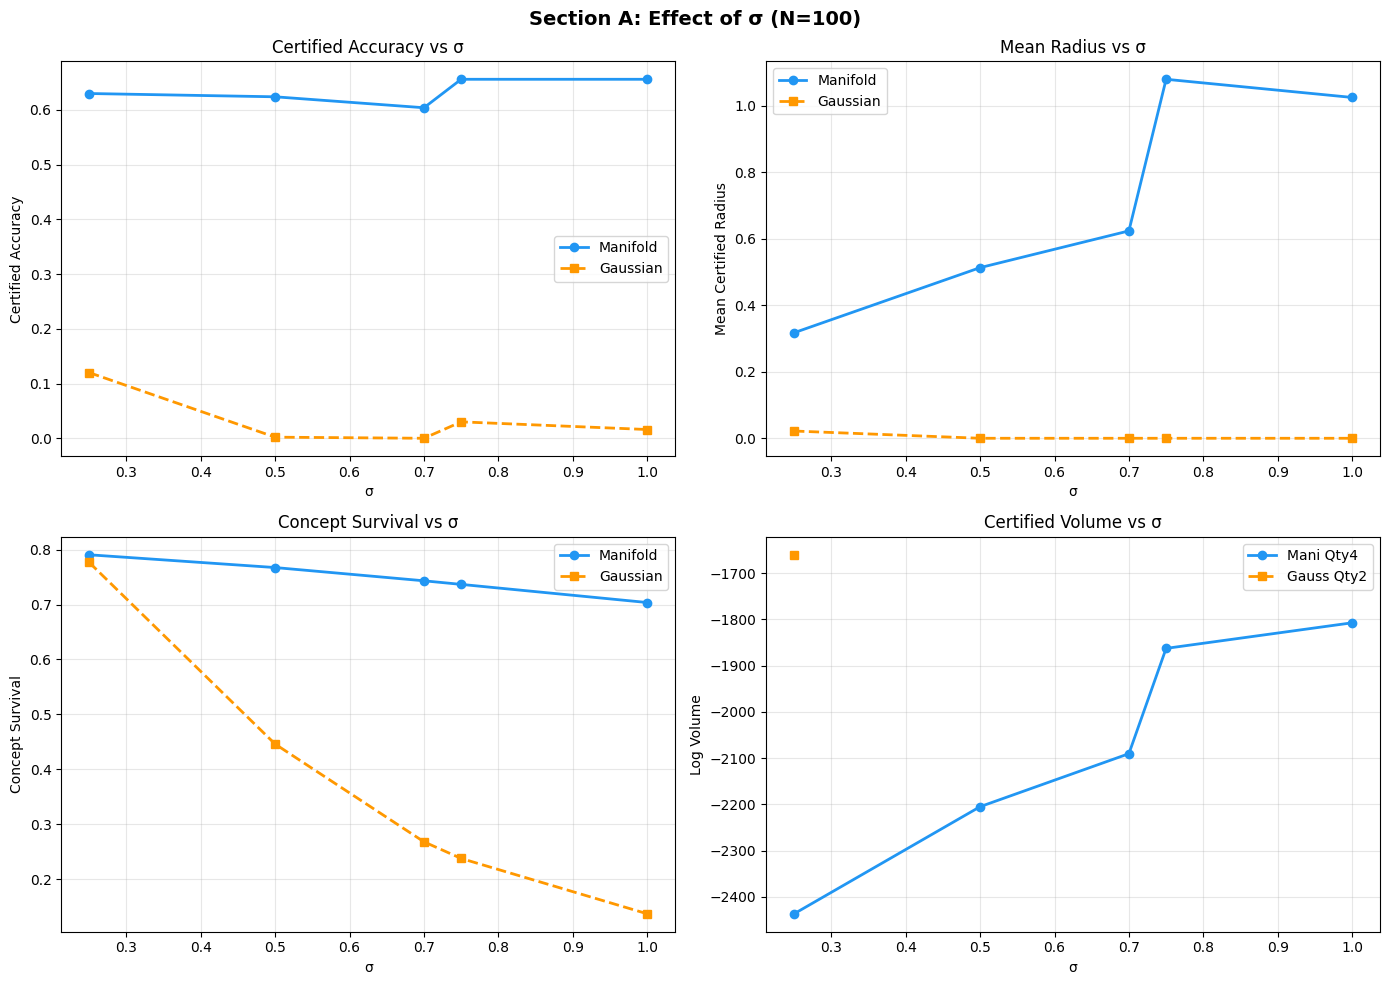

In [5]:
# ============================================================
# PLOTS A: σ sweep at fixed N=100
# ============================================================
import matplotlib.pyplot as plt

if sigma_results:
    s_vals = sorted(sigma_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cert Acc vs σ
    ax = axes[0, 0]
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'manifold')['cert_acc'] for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'gaussian')['cert_acc'] for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Certified Accuracy'); ax.set_title('Certified Accuracy vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Mean Radius vs σ
    ax = axes[0, 1]
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'manifold')['mean_r'] for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'gaussian')['mean_r'] for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Mean Certified Radius'); ax.set_title('Mean Radius vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Concept Survival vs σ
    ax = axes[1, 0]
    ax.plot(s_vals, [np.mean([r.get('mean_concept_survival_manifold', 0) for r in sigma_results[s]]) for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [np.mean([r.get('mean_concept_survival_gaussian', 0) for r in sigma_results[s]]) for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Concept Survival'); ax.set_title('Concept Survival vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Volume vs σ
    ax = axes[1, 1]
    ax.plot(s_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in sigma_results[s]]) for s in s_vals],
            'o-', color='#2196F3', label='Mani Qty4', linewidth=2)
    ax.plot(s_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in sigma_results[s]]) for s in s_vals],
            's--', color='#FF9800', label='Gauss Qty2', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Log Volume'); ax.set_title('Certified Volume vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Section A: Effect of σ (N={FIXED_N})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sigma_sweep_plots.png", dpi=150, bbox_inches="tight")
    plt.show()

In [ ]:
### Section B: N sweep (per σ)
How does the number of smoothing samples affect certification tightness? Loops over all σ values found in the grid.

In [ ]:
# ============================================================
# TABLES B: N sweep — for EVERY σ found in the grid
# ============================================================

# Find which sigmas actually have multiple N values
sigmas_with_n_sweep = {}
for sigma in SIGMAS:
    n_res = {n: grid[(sigma, n)] for n in N_VALUES if (sigma, n) in grid}
    if len(n_res) > 1:  # need at least 2 N values to be a sweep
        sigmas_with_n_sweep[sigma] = n_res

if not sigmas_with_n_sweep:
    print("No sigma has results for multiple N values. Skipping N sweep.")
else:
    for sigma, n_results in sorted(sigmas_with_n_sweep.items()):
        print(f"\n{'#'*80}")
        print(f"  σ = {sigma:.2f}  ({len(n_results)} N values: {sorted(n_results.keys())})")
        print(f"{'#'*80}")

        # --- B1: Downstream Accuracy ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            n_res = len(results)
            orig_correct = sum(1 for r in results if r['pred_orig'] == r['label_true'])
            m_correct = sum(1 for r in results if r['pred_manifold'] == r['label_true'])
            g_correct = sum(1 for r in results if r['pred_gaussian'] == r['label_true'])
            rows.append({
                'N': n_val, 'Orig Acc': f"{orig_correct/n_res*100:.1f}%",
                'Manifold Acc (↑)': f"{m_correct/n_res*100:.1f}%",
                'Gaussian Acc (↑)': f"{g_correct/n_res*100:.1f}%",
            })
        print(f"\nTABLE B1: DOWNSTREAM ACCURACY (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B2: Certified Downstream Accuracy ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            m = _class_stats_numeric(results, 'manifold')
            g = _class_stats_numeric(results, 'gaussian')
            rows.append({
                'N': n_val,
                'Mani CertAcc (↑)': f"{m['cert_acc']*100:.1f}%",
                'Gauss CertAcc (↑)': f"{g['cert_acc']*100:.1f}%",
                'Mani Abstain (↓)': f"{m['abstain']*100:.1f}%",
                'Gauss Abstain (↓)': f"{g['abstain']*100:.1f}%",
                'Mani MeanR (↑)': f"{m['mean_r']:.4f}",
                'Gauss MeanR (↑)': f"{g['mean_r']:.4f}",
            })
        print(f"\nTABLE B2: CERTIFIED DOWNSTREAM ACCURACY (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B3: Concept Certification ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            rows.append({
                'N': n_val,
                'Mani Survival (↑)': f"{np.mean([r.get('mean_concept_survival_manifold', 0) for r in results]):.3f}",
                'Gauss Survival (↑)': f"{np.mean([r.get('mean_concept_survival_gaussian', 0) for r in results]):.3f}",
                'Mani MeanR (↑)': f"{_safe_mean([r.get('mean_concept_radius_manifold', 0) for r in results]):.4f}",
                'Gauss MeanR (↑)': f"{_safe_mean([r.get('mean_concept_radius_gaussian', 0) for r in results]):.4f}",
            })
        print(f"\nTABLE B3: CONCEPT CERTIFICATION (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B4: Volume ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]
            v4 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in results])
            v2 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in results])
            rows.append({
                'N': n_val,
                'r_mani mean': f"{_safe_mean(r_manis):.4f}",
                'Qty4(Mani) mean': f"{v4:.1f}" if np.isfinite(v4) else "N/A",
                'Qty2(Iso k) mean': f"{v2:.1f}" if np.isfinite(v2) else "N/A",
            })
        print(f"\nTABLE B4: CERTIFIED VOLUME (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

In [ ]:
# ============================================================
# PLOTS B: N sweep — one 2×2 figure per σ
# ============================================================
for sigma, n_results in sorted(sigmas_with_n_sweep.items()):
    n_vals = sorted(n_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cert Acc vs N
    ax = axes[0, 0]
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'manifold')['cert_acc'] for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'gaussian')['cert_acc'] for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Certified Accuracy'); ax.set_title('Certified Accuracy vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Mean Radius vs N
    ax = axes[0, 1]
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'manifold')['mean_r'] for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'gaussian')['mean_r'] for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Mean Certified Radius'); ax.set_title('Mean Radius vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Concept Survival vs N
    ax = axes[1, 0]
    ax.plot(n_vals, [np.mean([r.get('mean_concept_survival_manifold', 0) for r in n_results[n]]) for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [np.mean([r.get('mean_concept_survival_gaussian', 0) for r in n_results[n]]) for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Concept Survival'); ax.set_title('Concept Survival vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Volume vs N
    ax = axes[1, 1]
    ax.plot(n_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in n_results[n]]) for n in n_vals],
            'o-', color='#2196F3', label='Mani Qty4', linewidth=2)
    ax.plot(n_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in n_results[n]]) for n in n_vals],
            's--', color='#FF9800', label='Gauss Qty2', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Log Volume'); ax.set_title('Certified Volume vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Section B: Effect of N (σ={sigma:.2f})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"n_sweep_sigma_{sigma:.2f}.png", dpi=150, bbox_inches="tight")
    plt.show()